# QSVT Design Tradeoffs: Degree, Error, and Boundedness

QSVT-style polynomial design has two practical constraints: approximate the
target function well and stay bounded on the relevant interval.

This notebook sweeps a few degrees and compares the diagnostics returned by the
package design helpers.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from qsvt.design import (
    design_filter_diagnostics,
    design_interval_projector_diagnostics,
    design_inverse_diagnostics,
    design_sign_diagnostics,
    design_sqrt_diagnostics,
)
from qsvt.qsvt import qsvt_compatibility_report


def fmt(value):
    if value is None:
        return "n/a"
    if isinstance(value, (list, tuple, set)):
        return ", ".join(fmt(item) for item in value)
    if isinstance(value, float):
        if value == 0.0:
            return "0"
        if abs(value) < 1e-3 or abs(value) >= 1e4:
            return f"{value:.2e}"
        return f"{value:.4g}"
    return str(value)


def display_table(title, rows, columns):
    rendered = [
        [str(header), *[fmt(accessor(row)) for row in rows]]
        for header, accessor in columns
    ]
    widths = [max(len(item) for item in row) for row in rendered]

    print(title)
    print("-" * len(title))
    for row, width in zip(rendered, widths):
        print(f"{row[0]:<{width}} : " + " | ".join(row[1:]))

## Sweep Several Design Families

Each row records the sampled fit error, boundedness margin, degree, and parity.
The smaller sample grids keep this notebook fast while preserving the qualitative
tradeoff.

In [2]:
builders = {
    "sign": lambda degree: design_sign_diagnostics(
        gamma=0.25,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
    "inverse": lambda degree: design_inverse_diagnostics(
        gamma=0.3,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
    "sqrt": lambda degree: design_sqrt_diagnostics(
        a=0.15,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
    "filter": lambda degree: design_filter_diagnostics(
        cutoff=0.45,
        sharpness=10.0,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
    "interval": lambda degree: design_interval_projector_diagnostics(
        lower=-0.35,
        upper=0.25,
        sharpness=10.0,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
}

degrees = [3, 5, 7, 9, 11]
records = []
for name, builder in builders.items():
    for degree in degrees:
        report = builder(degree)
        compatibility = qsvt_compatibility_report(
            report["coeffs"],
            bounded_num_points=801,
            attempt_synthesis=False,
        )
        records.append(
            {
                "Name": name,
                "Degree": degree,
                "max_error": report["max_error"],
                "bounded_margin": report["bounded_margin"],
                "Parity": compatibility["parity"],
                "is_bounded": compatibility["is_bounded"],
            }
        )

preview_rows = records[::5]
display_table(
    "Representative degree-3 designs",
    preview_rows,
    [
        ("Family", lambda row: row["Name"]),
        ("Degree", lambda row: row["Degree"]),
        ("Max error", lambda row: row["max_error"]),
        ("Bounded margin", lambda row: row["bounded_margin"]),
        ("Parity", lambda row: row["Parity"]),
        ("Bounded", lambda row: row["is_bounded"]),
    ],
)

Representative degree-3 designs
-------------------------------
Family   : sign | inverse | sqrt | filter | interval
Degree : 3 | 3 | 3 | 3 | 3
Max error : 0.5479 | 0.9892 | 0.06978 | 0.5407 | 0.4328
Bounded margin : 0 | 0.1963 | 0 | 0 | 0.3587
Parity : odd | odd | mixed | even | mixed
Bounded : True | True | True | True | True


## Error Usually Falls With Degree

The trend is not perfectly monotone for every bounded fit, but the plot gives a
quick first pass at degree selection.

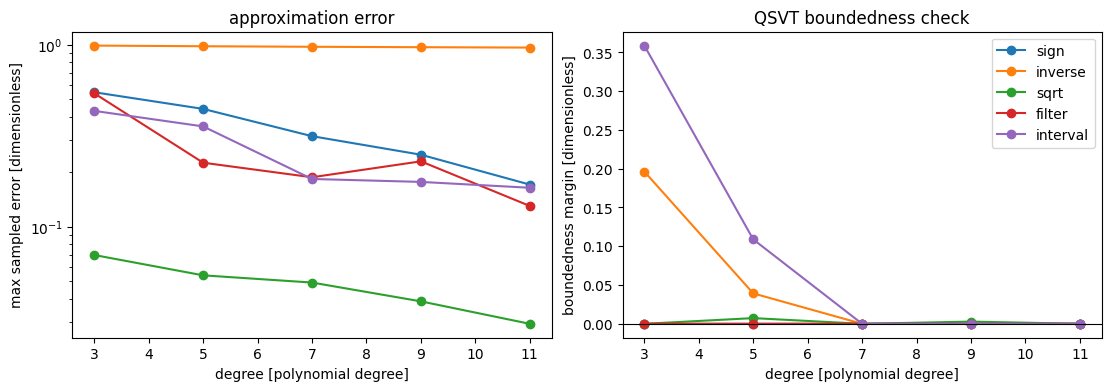

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for name in builders:
    subset = [row for row in records if row["Name"] == name]
    axes[0].plot(
        [row["Degree"] for row in subset],
        [row["max_error"] for row in subset],
        marker="o",
        label=name,
    )
    axes[1].plot(
        [row["Degree"] for row in subset],
        [row["bounded_margin"] for row in subset],
        marker="o",
        label=name,
    )

axes[0].set_yscale("log")
axes[0].set_xlabel("degree [polynomial degree]")
axes[0].set_ylabel("max sampled error")
axes[0].set_title("approximation error")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("degree [polynomial degree]")
axes[1].set_ylabel("boundedness margin")
axes[1].set_title("QSVT boundedness check")
axes[1].legend(loc="best")

## Inspect One Chosen Design

After narrowing the degree sweep, inspect the target, approximation, and error
curves for a specific family.

Max error: 0.1632978061045941
Bounded margin: 1.1102230246251565e-16


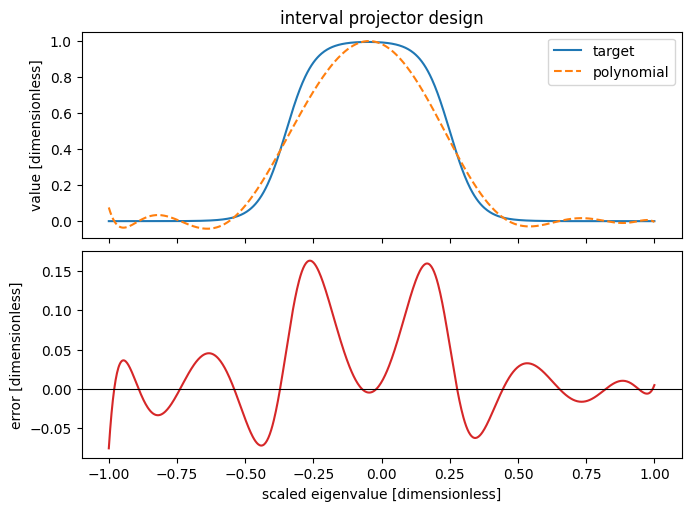

In [4]:
chosen = design_interval_projector_diagnostics(
    lower=-0.35,
    upper=0.25,
    sharpness=10.0,
    degree=11,
    num_points=801,
    bounded_num_points=1001,
)
xs = chosen["xs"]

fig, axes = plt.subplots(2, 1, figsize=(6.8, 5.0), sharex=True, constrained_layout=True)
axes[0].plot(xs, chosen["target_values"], label="target")
axes[0].plot(xs, chosen["polynomial_values"], "--", label="polynomial")
axes[0].set_ylabel("value")
axes[0].set_title("interval projector design")
axes[0].legend(loc="best")
axes[1].plot(xs, chosen["errors"], color="tab:red")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("scaled eigenvalue")
axes[1].set_ylabel("error")

print("Max error:", chosen["max_error"])
print("Bounded margin:", chosen["bounded_margin"])
assert chosen["bounded_margin"] > -1e-10